# SASHIMI-W: usage walkthrough

## Goal
Configure a WDM mass and transfer convention, produce a catalogue, and use the satellite observable wrappers.

Run **Restart Kernel and Run All**. Every code cell is required, including the checks. These small grids teach the API; they are not converged predictions or a replacement for scientific regression tests.

## Setup
Use Python 3.12 in a clean virtual environment, from this repository's `itamae-migration` checkout:
```sh
python -m venv .venv
source .venv/bin/activate
python -m pip install --upgrade pip
python -m pip install "itamae @ git+https://github.com/gomeshun/itamae.git@1c5b1ad67725671fd4dc1a2306d2731ba337e563"
python -m pip install . numpy scipy matplotlib astropy colossus h5py numexpr tqdm nbformat nbclient ipykernel
python -m ipykernel install --user --name sashimi-walkthrough
```
Select that kernel. ITAMAE means this project's GitHub package; do not substitute an unrelated package with the same PyPI name. No data download is performed by notebook cells. F uses its packaged Planck power table and a temporary cache.


In [1]:
import sys, tempfile
from pathlib import Path
from importlib.metadata import version
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from itamae.provenance import source_revision
packages = ['itamae', 'sashimi-w']
display({p: {"version": version(p), "source_revision": source_revision(p)} for p in packages})
print(sys.version)
rng = np.random.default_rng(20260907)
workspace = tempfile.TemporaryDirectory(prefix="sashimi-w-walkthrough-")
work = Path(workspace.name)

3.12.13 (main, Aug  7 2026, 02:25:39) [Clang 22.1.3 ]


{'itamae': {'version': '0.1.0a4',
  'source_revision': '1c5b1ad67725671fd4dc1a2306d2731ba337e563'},
 'sashimi-w': {'version': '0.1.0a1',
  'source_revision': '676386919f638a6f460a3ec50304384373e0d6fc'}}

## WDM conventions and half-mode scale
The published q=5 and standard T² q=10 conventions differ physically. Always record the convention; changing it is not a numerical backend substitution.

In [2]:
from sashimi_w_itamae import subhalos
from sashimi_w_itamae_migration import PUBLISHED_Q5, STANDARD_T2_Q10
parameters = {'M0': 10000000000.0, 'redshift': 0.0, 'dz': 0.5, 'zmax': 1.0, 'N_ma': 12, 'sigmalogc': 0.128, 'N_herm': 3, 'logmamin': 6.0, 'logmamax': 8.0, 'sigmafac': 0, 'N_hermNa': 4, 'profile_change': True}
display(parameters)
model = subhalos(mass_wdm=2., physics_mode="consistent", wdm_power_convention=PUBLISHED_Q5)
alternative = subhalos(mass_wdm=2., physics_mode="consistent", wdm_power_convention=STANDARD_T2_Q10)
print("half-mode k [h/Mpc]:", model.half_mode_wavenumber(), alternative.half_mode_wavenumber())
catalog = model.rs_rhos_catalog_calc(**parameters)

half-mode k [h/Mpc]: 20.114255416329843 20.114255416329843


{'M0': 10000000000.0,
 'redshift': 0.0,
 'dz': 0.5,
 'zmax': 1.0,
 'N_ma': 12,
 'sigmalogc': 0.128,
 'N_herm': 3,
 'logmamin': 6.0,
 'logmamax': 8.0,
 'sigmafac': 0,
 'N_hermNa': 4,
 'profile_change': True}

## Inspect the catalogue contract
Rows are quadrature nodes, not individual satellites. `weight_final` combines the stored population and survival factors. Inspect the metadata before comparing physics modes or converting units; column names alone do not establish a unit convention.

In [3]:
from itamae.types import WeightedSubhaloCatalog
print("nodes:", catalog.shape, "expected surviving count:", float(catalog.weight_final.sum()))
print("columns:", sorted(catalog.columns))
print("weight factors:", sorted(catalog.weights))
display(catalog.metadata)
assert np.all(np.isfinite(catalog.weight_final))
assert np.all(catalog.weight_final >= 0)
assert catalog.weight_final.sum() > 0

nodes: (72,) expected surviving count: 0.002602698751680504
columns: ['c_t', 'm200_acc', 'm_bound', 'r_s', 'r_s_acc', 'rho_s', 'rho_s_acc', 'survive', 'z_acc']
weight factors: ['weight_base', 'weight_concentration', 'weight_survival']


mappingproxy({'schema_version': '1.0',
              'model_identifier': 'sashimi-w:wdm:m_wdm_keV=2:physics=consistent:power=published-q5:itamae-migration:v5',
              'backend_identifier': 'array=numpy;cosmology=native-flatlcdm:Om=0.27:h=0.7;units=native-units:1.0',
              'mass_wdm_keV': 2.0,
              'wdm_power_convention': 'published-q5',
              'wdm_power_formula_role': 'q5-expression-used-as-power-ratio',
              'wdm_power_q': 5.0,
              'wdm_transfer_nu': 1.12,
              'half_mode_definition': 'P_WDM/P_CDM=0.5',
              'half_mode_power_ratio': 0.5,
              'half_mode_wavenumber_h_per_mpc': 20.114255416329843,
              'omega_m0': 0.27,
              'omega_lambda0': 0.73,
              'cosmology_parameters': {'omega_m0': 0.27,
               'omega_lambda0': 0.73,
               'h': 0.7},
              'growth_normalized_at_z0': True,
              'variance_growth_power': 2,
              'variance_mass_unit': 'Ms

## Select a population and plot its weighted mass function
A histogram sums expected counts, then division by the logarithmic bin width gives dN/dln M. Changing the mass range changes the population included; this is not a convergence test.

weighted bound mass: 53509.67805174719


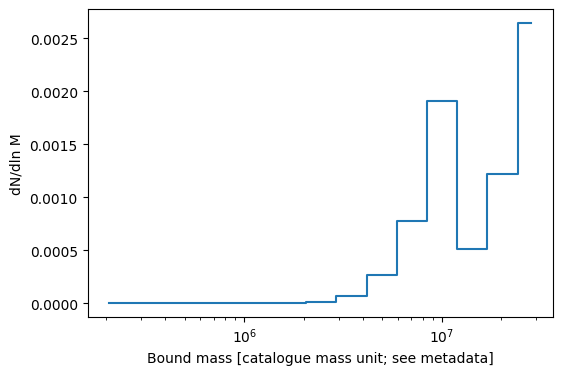

In [4]:
mass = np.asarray(catalog.columns["m_bound"])
positive = (mass > 0) & (catalog.weight_final > 0)
selected = catalog.select(positive)
edges = np.geomspace(mass[positive].min()*0.99, mass[positive].max()*1.01, 16)
counts, edges = selected.weighted_histogram("m_bound", bins=edges)
np.testing.assert_allclose(counts.sum(), selected.weight_final.sum())
fig, ax = plt.subplots(figsize=(6, 4))
ax.step(np.sqrt(edges[:-1]*edges[1:]), counts/np.diff(np.log(edges)), where="mid")
ax.set(xscale="log", xlabel="Bound mass [catalogue mass unit; see metadata]", ylabel="dN/dln M")
plt.show()
print("weighted bound mass:", selected.weighted_sum(selected.columns["m_bound"]))

## Save and reload without pickle
NPZ retains the catalogue's columns, factorized weights and metadata. The round-trip checks make this notebook useful as a migration smoke test.

In [5]:
path = work / "catalog.npz"
catalog.to_npz(path)
restored = WeightedSubhaloCatalog.from_npz(path)
for name in catalog.columns:
    np.testing.assert_array_equal(restored.columns[name], catalog.columns[name])
np.testing.assert_array_equal(restored.weight_final, catalog.weight_final)
assert restored.metadata == catalog.metadata
print("NPZ round trip passed")

NPZ round trip passed


## Observable wrappers
The wrappers preserve their legacy output conventions; the catalogue exposes the canonical metadata contract. Compare like units when combining the two interfaces.

satellite counts / velocity threshold: 0.002602698751680505 0.0


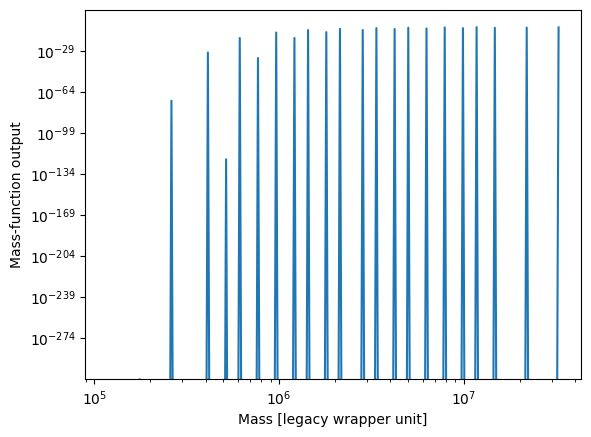

In [6]:
mass_axis, density = model.subhalo_distr(**parameters)
assert np.all(np.isfinite(density))
plt.loglog(mass_axis, density); plt.xlabel("Mass [legacy wrapper unit]"); plt.ylabel("Mass-function output"); plt.show()
number, accretion_mass, cumulative = model.N_sat(**parameters)
vnumber, vmax, vcumulative = model.N_sat_Vthres(Vpeak_max=18, **parameters)
print("satellite counts / velocity threshold:", number, vnumber)

## Coverage and next steps

| Area | Runnable example |
|---|---|
| WDM physics | Mass, transfer conventions, half-mode |
| Population | Structure/evolution catalogue |
| Catalogue | Canonical metadata, weights, NPZ |
| Observables | Mass distribution, satellite counts, velocity threshold |

See `itamae_migration_demo.ipynb` for legacy unit conversion and consistent-variance comparisons. The small grid here does not establish convergence near the WDM cutoff.

When a public feature is added or migrated, update this table, its runnable example and its checks in the same PR. Existing migration demos remain the detailed numerical comparison reference; passing this walkthrough does not close their separate regeneration work.

In [7]:
workspace.cleanup()
print("All walkthrough checks passed")

All walkthrough checks passed
